# <a id='toc1_'></a>[Technische Prüfungen in klinischen und epi Daten](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Technische Prüfungen in klinischen und epi Daten](#toc1_)    
  - [Hintergrund](#toc1_1_)    
  - [⚙️ settings](#toc1_2_)    
  - [Datenstand ⏱️](#toc1_3_)    
  - [Qualitätsprüfungen](#toc1_4_)    
    - [⚠️ geschlecht_missing](#toc1_4_1_)    
    - [✅ verstorben_missing](#toc1_4_2_)    
    - [⚠️ diagnose_missing](#toc1_4_3_)    
    - [⚠️ inzidenzort_missing](#toc1_4_4_)    
    - [✅ geschlecht_icd_konflikt](#toc1_4_5_)    
    - [⚠️ datum_missing](#toc1_4_6_)    
    - [datum_fehlerhaft](#toc1_4_7_)    
    - [nach hat_todesursache bei Nicht-Verstorbenen](#toc1_4_8_)    
  - [⚠️ Duplikate](#toc1_5_)    
    - [Echte Duplikate](#toc1_5_1_)    
    - [Duplikatverdacht](#toc1_5_2_)    
      - [Verteilung nach Inzidenzort](#toc1_5_2_1_)    
      - [Verteilung nach Diagnosejahr](#toc1_5_2_2_)    
      - [Verteilung nach ICD10](#toc1_5_2_3_)    
      - [Verteilung der Gruppen mit gleichen Merkmalen](#toc1_5_2_4_)    
  - [Datensatz](#toc1_6_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

<br>

## <a id='toc1_1_'></a>[Hintergrund](#toc0_)
- Ziel der Auswertungen ist es, Qualitätsprüfungen auf **technischer** Ebene darzustellen
- im Abgrenzung zu den **inhaltlichen** Prüfungen des klinischen Datenberichtes sollen hier eher Auffälligkeiten des Verarbeitungsprozesses sichtbar werden, z.B. missings / Konflikte bei zentralen Variablen wie Datumsangaben, Geschlecht etc.
- die Auswertungen sind angelehnt an die bei den epi Daten etablierten _ABC Prüfungen_ (siehe `Bericht zur Datenqualität (epi2023)`)
- die Abgrenzung dieses Dokumentes zum DQ Bericht epi ist derzeit nicht zufriedenstellend gelöst und muss zukünftig verbessert werden
- dargestellt sind hier jeweils Auffälligkeiten sowohl in den klinischen als auch in den epi Daten
- weiterhin nehmen wir bei keinem dieser Prüfungen eine Korrektur in den **klinischen Daten** vor

<!-- ## <a id='toc1_2_'></a>[Zusammenfassung ⚖️](#toc0_)
- [fehlendes Geschlecht](#toc1_4_1_) tritt nicht auf in den klinischen Daten, in den epi Daten überwiegend in `06-HE`
- für [fehlende Diagnose](#toc1_4_3_) bei den klinischen Daten gibt es einige wenige Fälle in `13-MV` und `16-TH`. Für die epi Daten ist eine Bewertung schwierig aufgrund der vielfältigen Bearbeitungsschritte nach Lieferung
- fehlender Inzidenzort tritt in den klinischen Daten nur in `13-MV` auf. Bei den epi Daten wird diese Variable bei missings auto-korrigiert 
- Widerspruch zwischen Geschlecht und Diagnose ist in den klinischen Daten eine Randerscheinung, in den epi Daten treten diese Kombinationen inzwischen nicht mehr auf
- fehlende Datumsangaben sind in den klinischen Daten in etwa proportional zur Registergrösse, bei den epi Daten überwiegend in `10-SL`
- [echte Duplikate](#toc1_5_1_) (gleiches set an Merkmalen und gleiche ID) für klinische Daten kommen ausschliesslich aus `09-BY`, bleiben aber Randfälle
- [Duplikatverdachtsfälle](#toc1_5_2_) sind deutlich weniger auffällig als letztes Jahr. Diese verteilen sich hauptsächlich auf `11-BE`, `09-BY` und `03-NI`, was möglicherweise an lokalen Häufungen von Fällen mit gleichem Inzidenzort liegt -->

<br>

## <a id='toc1_2_'></a>[⚙️ settings](#toc0_)

In [1]:
import os
from pathlib import Path
import pandas as pd
from importlib import metadata as md
import duckdb as ddb
from connection_helper import sql
from pandas_plots import tbl, pls, hlp
import duckdb as ddb
import datetime as dt
import numpy as np

os.environ["DY_MAX"] = "2024"  # set before import
from mod.filters import *

os.environ["RENDERER"] = "svg"
os.environ['THEME']='light'
hlp.show_package_version()

dir_files=Path(".local/files")
dir_db=Path("C://temp") if hlp.get_os(hlp.OperatingSystem.WINDOWS) else Path(os.path.expanduser("~/tmp"))

file_db_clin = dir_db/'2026-03-04_data_clin.duckdb'
file_db_clin_meta = dir_db/'2026-03-04_internal_clin.duckdb'
file_db_epi = dir_db/'2026-03-03_data_epi.duckdb'
# file_db_epi_meta = dir_db/'2026-03-03_meta_epi.duckdb'

if not all([file_db_clin.exists(), file_db_epi.exists(), file_db_clin_meta.exists()]):
    raise FileNotFoundError()

URL_V2 = 'https://gitlab.opencode.de/robert-koch-institut/zentrum-fuer-krebsregisterdaten/cancerdata-references/-/raw/main/data/v2/'

🐍 3.12.8 | 📦 pandas: 2.3.3 | 📦 numpy: 1.26.4 | 📦 duckdb: 1.5.0 | 📦 pandas-plots: 1.4.6


<br>

## <a id='toc1_3_'></a>[Datenstand ⏱️](#toc0_)

In [3]:
sql.print_meta(file_db_clin)
print()
sql.print_meta(file_db_epi)

database file:           2026-03-04_data_clin.duckdb
data tag:                v2.4
last kkr data import:    2026-02-26
sql table created:       2026-03-04 10:17:13
doi:                     -
document created:        2026-04-20 18:28:24

database file:           2026-03-03_data_epi.duckdb
data tag:                epi2025_beta2
sql table created:       2026-03-03 09:47:44
doi:                     -
document created:        2026-04-20 18:28:24


In [5]:
con = ddb.connect()
con.execute("PRAGMA disable_progress_bar;")
con.execute(f"ATTACH DATABASE '{file_db_clin}' AS clin (READ_ONLY);")
con.execute(f"ATTACH DATABASE '{file_db_epi}' AS epi (READ_ONLY);")
con.execute(f"ATTACH DATABASE '{file_db_clin_meta}' AS clin_meta (READ_ONLY);")
con.execute("SET SCHEMA 'epi';")

# dim_dig, dim_dsich_clin, dim_dsich_epi, dim_grading, dim_grading_clin, dim_grading_epi, dim_icd10, dim_icd10_3d, dim_landkreis, dim_lieferregister, dim_op_intention, dim_tnm_t, dim_tnm_uicc, dim_tree=sql.unpack_files_to_duckdb(
#     dir=Path("data/dim"),
#     con=con,
#     ext="csv",
#     prefix="dim_",
#     # debug=True,
#     # verbose=True,
# )
dim_lieferregister = con.sql("select * from clin.dim_lieferregister").filter("kkr <> 'Total'")

dim_landkreis = sql.load_file_to_duckdb(con=con, path=URL_V2 + "Klassifikationen/landkreis.csv", sep=";")

Tumor = con.sql("select * from clin.Tumor")
Patient= con.sql("select * from clin.Patient")
_meta = con.sql("select * from clin._meta")

Tumor4 = con.sql("select * from epi.Tumor4")

db_tum_id = con.sql("select * from clin_meta._tum_id")

In [37]:
Batches = con.table("_batches")
Checks = con.table("_checks")
ColumnCheck = con.table("_columncheck")
Frequencies = con.table("_frequencies")
# _meta_meta = con.sql("select * from meta._meta;")

df_checks = Checks.join(dim_lieferregister, "EKRNR=code").project("ID,kkr as EKRNR,ColumnCheckID,Anzahl,BatchID,DJahr").to_df()
df_freqs = (
    Frequencies.project(
        "*, concat(cast(BatchID as varchar),' | ', cast(cast(BatchZeit as date) as varchar)) as batch_label"
    )
    .join(dim_lieferregister, "EKRNR=code")
    .project("ID,kkr as EKRNR,Alias,Wert,DJahr,Anzahl,Stufe,BatchID,BatchZeit,batch_label")
    .to_df()
)


In [39]:

# df_freqs["EKRNR"] = df_freqs["EKRNR"].astype(int).replace(dim_lieferregister.to_df()["kkr"].to_dict())
# df_checks["EKRNR"] = df_checks["EKRNR"].astype(int).replace(dim_lieferregister.to_df()["kkr"].to_dict())
df_batches= Batches.to_df()
df_columnchecks= ColumnCheck.to_df().set_index('ColumnCheckID')
df_checks = df_checks.join(df_columnchecks, on='ColumnCheckID')
df_checks["check_label"] = df_checks.apply(lambda x: f"{x['Alias']}[{x['ColumnCheckID']}]", axis=1)
df_checks= df_checks[["EKRNR","Anzahl","BatchID","DJahr","check_label","ColumnCheckID"]]

In [40]:
batch_max=df_checks['BatchID'].max()
batch_list = [batch_max,418,416,399,360]
batch_min=399
db_list_dy="(2024)"


print(f"\n{'aktuellster batch': <32}{batch_max}")
print(f"{'aktuellstes Diagnosejahr 📆': <30} {db_list_dy}")


aktuellster batch               425
aktuellstes Diagnosejahr 📆     (2024)


## <a id='toc1_6_'></a>[Anteil Mehrfachtumore](#toc0_)
- Metrik: Anteil Tumore mit `A_Mehrfachmeldung`
- diese Tumore werden vom ZfKD ausgeschlossen

> 💡 **ZfKD**
> 
> für `13-NI`,`14-SN` und `15-ST` ermittelt das ZfKD sichtbar erhöhte Anteile an Mehrfachtumoren für DJ seit Beginn der klin. Registrierung

In [28]:
_filters = [
    # FILTERS_VALID,
    # FILTERS_C,
    # FILTERS_NO_C44,
    ("z_dy between 2010 and 2024","DJ 2010-2024"),
    ("GKZbl::tinyint <= 16", "nur gültige BL"),
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from epi.tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    with t1 as (
        select
            GKZbl_label as bl,
            GKZbl,
            z_is_dco,
            case when IARC like '%A_Mehrfach%' then 1 else 0 end as is_multiple,
            z_dy,
            z_icd10_3d,
            is_deleted,
        from epi.tumor_epi_clin_all
    ),
    t2 as (
        select  bl,
                z_dy,
                count(*) as cnt,
                sum(is_multiple) as sum_multiple,
                sum(is_multiple) / cnt * 100 as pct_multiple,
        from    t1
        where {_filter}
        group by all
        union
        select  'Total' as bl,
                z_dy,
                count(*) as cnt,
                sum(is_multiple) as sum_multiple,
                sum(is_multiple) / cnt * 100 as pct_multiple,
        from    t1
        where {_filter}
        group by all
    )
    select * from t2
    """
).to_df()

# _df

tbl.pivot_df(
    _df[["bl", "z_dy", "pct_multiple"]],
    swap=True,
    precision=2,
    pct_axis="",
    total_axis="",
    font_size_th=12,
    font_size_td=11,
)

<!-- START_TOKEN -->

n = 17_569_016                     (100.0%) ██████████████████████████████
└ [DJ 2010-2024]:   n = 11_641_922  (66.3%) ░░░░░░░░░░░███████████████████
└ [nur gültige BL]: n = 11_632_852  (66.2%) ░░░░░░░░░░░███████████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2010 and 2024
and GKZbl::tinyint <= 16
```

</details>

bl,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-GKR,12-BB,13-MV,14-SN,15-ST,16-TH,Total
z_dy,,,,,,,,,,,,,,,,,
2010,0.10,2.16,0.95,0.03,0.07,0.15,0.11,0.33,0.18,2.78,0.51,0.78,0.73,1.45,0.76,1.21,0.48
2011,0.01,2.22,1.02,0.10,0.09,0.19,0.14,0.41,0.18,2.40,0.63,0.87,1.08,1.46,0.67,1.22,0.50
2012,0.02,1.87,1.04,0.06,0.09,0.14,0.19,0.43,0.17,2.63,0.73,0.85,1.00,1.50,0.70,1.22,0.51
2013,0.01,1.67,1.23,0.11,0.12,0.17,0.25,0.72,0.21,3.19,0.72,0.91,1.02,1.43,0.70,1.38,0.59
2014,0.01,1.28,1.29,0.14,0.18,0.24,0.32,0.86,0.20,5.31,0.76,0.80,0.97,1.45,0.85,1.31,0.66
2015,0.02,1.04,1.42,0.41,0.23,0.10,0.42,0.78,0.17,4.83,0.82,0.76,1.09,1.32,0.89,1.29,0.67
2016,0.24,0.97,1.34,0.38,0.36,0.07,0.63,0.75,0.24,4.80,1.03,1.00,1.05,1.35,1.04,1.23,0.74
2017,0.42,0.90,1.24,0.37,0.64,0.17,0.83,0.76,0.26,4.83,1.73,1.42,1.12,1.53,0.83,1.51,0.88
2018,0.33,0.87,1.37,0.35,0.40,0.19,0.86,0.71,0.26,4.74,1.61,1.48,1.14,1.61,1.10,1.29,0.83


<br>

## <a id='toc1_7_'></a>[Plausibilitätsprüfungen](#toc0_)
**Filter**
- **es ist jeweils nur das aktuellste DJ berücksichtigt (aktuell `epi2025`: 2024, zum Vergleich `epi2024`: 2023)**

Die Tabellen sind zur besseren Lesbarkeit nun aufgeteilt nach den Plausibilitätsprüfungen ([pdf hier verfügbar](https://www.krebsregisterverbund.de/attachments/download/8743/Plausibilit%C3%A4tspr%C3%BCfungen_details.pdf))
- `A`: Fälle ausgeschlossen
- `B`: Fälle markiert
- `C`: Fälle (auto) korrigiert

Spalten
- `cnt_epi2024`: Absolute Fallzahl der checks für das in diesem Datensatz höchste DJ (2023)
- `cnt_now`: Absolute Fallzahl der checks für das im aktuellen Datensatz höchsten DJ (2024)
- `pct_epi2024`: Anteil Fallzahl der checks an allen Fällen für das in diesem Datensatz höchste DJ (2023)
- `pct_now`: Anteil Fallzahl der checks an allen Fällen für das im aktuellen Datensatz höchste DJ (2024)
- _(Absolute Fallzahlen = nach Abzug der A-Prüfungen)_

Die markierten Fälle können im übermittelten Datensatz geprüft werden, Beispiel: 
<details>
    <summary>click</summary>

```sql
    select * 
    from Tumor4 
    where IARC like '%A_Mehrfach%'
```

</details>

In [41]:
def show_checks2(df_in: pd.DataFrame, reg: str) -> None:
    
    # db = con.from_df(df_in)
    db_total= con.sql(f"""--sql
        select *
        from df_in
        where BatchID = {batch_max}
        and EKRNR = '{reg}'
        and DJahr <> 'alt'
    """)
    
    
    if db_total.count("*").fetchone()[0] == 0:
        print("❌")
        return

    def get_ser(
        df_in: pd.DataFrame, batch_id: int, reg: str, suffix: str
    ) -> pd.DataFrame:
        df = df_in.copy()

        total = df.loc[
            (df["BatchID"] == batch_id)
            & (df["EKRNR"] == reg)
            & (df["DJahr"] != "alt")
            & (df["check_label"] == "I_Fallzahl[48]"),
            ["BatchID", "check_label", "Anzahl"],
        ].iloc[0, -1]

        df_out = df.loc[
            (df["BatchID"] == batch_id) & (df["EKRNR"] == reg) & (df["DJahr"] != "alt"),
            ["BatchID", "check_label", "Anzahl"],
        ]

        df_out["pct"] = df_out["Anzahl"] / total * 100
        return (
            df_out.rename(columns={"Anzahl": "cnt_" + suffix, "pct": "pct_" + suffix})
            .iloc[:, 1:]
            .reset_index(drop=True)
        )

    df0 = get_ser(df_checks, 418, reg, "epi2024")
    df1 = get_ser(df_checks, batch_max, reg, "now")

    df = (
        pd.merge(df0, df1, on="check_label", how="outer")
        .set_index("check_label")
        .iloc[:, [0, 2, 1, 3]]
    )
    df_ab = df[df.index.str.startswith(("A_", "B_","I_"))]
    df_a = df[df.index.str.startswith(("A_","I_"))]
    df_b = df[df.index.str.startswith(("B_","I_"))]
    df_c = df[df.index.str.startswith(("C_","I_"))]
    display(tbl.show_num_df(df_a, total_axis="", data_bar_axis="x", col1_width=350,font_size_th=13,font_size_td=11, image_scale="55%",))
    display(tbl.show_num_df(df_b, total_axis="", data_bar_axis="x", col1_width=350,font_size_th=13,font_size_td=11, image_scale="55%",))
    display(tbl.show_num_df(df_c, total_axis="", data_bar_axis="x", col1_width=350,font_size_th=13,font_size_td=11, image_scale="55%",))
    return

<br>

### <a id='toc1_7_1_'></a>[⚠️ 01-SH](#toc0_)
- `B_TOD_Ja_Aber_Kein_SJ`: 0 -> 4%
- alle Fälle wurden korrigiert laut `C_TOD=1_korrigiert_aufgrund_Sterbeangaben`

In [42]:
# show_checks(df_checks, batches=batches, reg='01-SH', relative=False)
show_checks2(df_checks, "01-SH")

<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_SEX_fehlerhaft[66],1,nan,0,nan
A_ICD10_keineAuswertung[54],1,nan,0,nan
A_Mehrfachmeldung[37],121,132,0,0
I_Fallzahl[48],34_512,36_307,100,100


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],12,14,0,0
B_DCO_DDIMP_inkonsistent[39],8,8,0,0
B_DIG_HISC_unplausibel[70],44,53,0,0
B_DIG_ICDO3_unplausibel[69],nan,1,nan,0
B_DSICH_HISC_unplausibel[72],130,102,0,0
B_Entscheidung_Mehrfachtumor_unplausibel[82],4,9,0,0
B_GRAD_HISC_unplausibel[85],44,45,0,0
B_HISC_ICDO3_unplausibel[55],222,209,1,1
B_TNMM_GROBST_unplausibel[78],109,95,0,0


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DIG_korrigiert[64],2,4,0,0
C_HISC_korrigiert[56],5,7,0,0
C_ICD10DREI_korrigiert[80],156,192,0,1
C_ICDO3_korrigiert[52],43,43,0,0
C_LOKS_korrigiert[84],137,194,0,1
C_SJ>MaxJahr[14],2_555,nan,7,nan
C_TOD=1_korrigiert_aufgrund_Sterbeangaben[74],nan,1_511,nan,4
I_Fallzahl[48],34_512,36_307,100,100


### <a id='toc1_7_2_'></a>[✅ 02-HH](#toc0_)

In [43]:
show_checks2(df_checks, "02-HH")

<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_Mehrfachmeldung[37],176,136,1,1
A_SEX_fehlerhaft[1],1,4,0,0
I_Fallzahl[48],18_011,17_987,100,100


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],6,9,0,0
B_DCO_DDIMP_inkonsistent[39],33,25,0,0
B_DIG_HISC_unplausibel[70],197,169,1,1
B_DSICH_HISC_unplausibel[72],243,250,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],nan,4,nan,0
B_GRAD_HISC_unplausibel[85],19,20,0,0
B_HISC_ICDO3_unplausibel[55],318,269,2,1
I_Fallzahl[48],18_011,17_987,100,100


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DJ_korrigiert_aufgrund_DSICH[43],81,76,0,0
C_HISC_korrigiert[56],6,16,0,0
C_ICD10DREI_korrigiert[80],58,57,0,0
C_ICDO3_korrigiert[52],2,3,0,0
C_LOKS_korrigiert[84],216,237,1,1
I_Fallzahl[48],18_011,17_987,100,100


### <a id='toc1_7_3_'></a>[✅ 03-NI](#toc0_)

In [44]:
# show_checks(df_checks, batches=batches, reg='03-NI', relative=False)
show_checks2(df_checks, "03-NI")

<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_keineAuswertung[54],147,147,0,0
A_Mehrfachmeldung[37],1_256,2_010,1,2
A_Zeitangaben_fehlerhaft[58],2,7,0,0
I_Fallzahl[48],86_331,84_692,100,100


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],35,55,0,0
B_DCO_DDIMP_inkonsistent[39],101,90,0,0
B_DIG_HISC_unplausibel[70],420,386,0,0
B_DSICH_HISC_unplausibel[72],697,704,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],1,1,0,0
B_GRAD_HISC_unplausibel[85],125,136,0,0
B_HISC_ICDO3_unplausibel[55],1_175,1_092,1,1
B_PatAngaben_inkonsistent[60],2,12,0,0
B_TNMM_GROBST_unplausibel[78],2,3,0,0


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DIG_korrigiert[64],nan,15,nan,0
C_DJ_korrigiert_aufgrund_DSICH[43],7,11,0,0
C_HISC_korrigiert[56],558,289,1,0
C_ICD10DREI_korrigiert[80],1_235,1_983,1,2
C_LOKS_korrigiert[84],516,378,1,0
C_SJ>MaxJahr[14],6_518,6_002,8,7
C_TNMx_korrigiert[44],166,121,0,0
C_TOD=1_korrigiert_aufgrund_Sterbeangaben[74],5,39,0,0
I_Fallzahl[48],86_331,84_692,100,100


### <a id='toc1_7_4_'></a>[✅ 04-HB](#toc0_)

In [45]:
show_checks2(df_checks, "04-HB")

<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_keineAuswertung[54],4,5,0,0
A_Mehrfachmeldung[37],25,14,0,0
A_SEX_fehlerhaft[1],2,nan,0,nan
I_Fallzahl[48],5_068,4_687,100,100


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],6,6,0,0
B_DCO_DDIMP_inkonsistent[39],4,2,0,0
B_DIG_HISC_unplausibel[70],34,85,1,2
B_DSICH_HISC_unplausibel[72],48,32,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],1,1,0,0
B_GRAD_HISC_unplausibel[85],12,8,0,0
B_HISC_ICDO3_unplausibel[55],85,114,2,2
B_TNMT_DIG_unplausibel[20],5,3,0,0
B_TNMx_ICD10_unplausibel[76],nan,5,nan,0


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DIG_korrigiert[64],nan,1,nan,0
C_HISC_korrigiert[56],3,9,0,0
C_ICD10DREI_korrigiert[80],16,13,0,0
C_ICDO3_korrigiert[52],4,nan,0,nan
C_LOKS_korrigiert[84],81,69,2,1
I_Fallzahl[48],5_068,4_687,100,100


### <a id='toc1_7_5_'></a>[⚠️ 05-NW](#toc0_)
- unverändert hohe werte bei `A_EKRNR_GKZ_unplausibel`

In [46]:
# show_checks(df_checks, batches=batches, reg='05-NW', relative=True)
show_checks2(df_checks, "05-NW")

<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_EKRNR_GKZ_unplausibel[83],21_338,22_483,11,12
A_ICD10_keineAuswertung[54],748,682,0,0
A_Mehrfachmeldung[37],255,216,0,0
I_Fallzahl[48],202_655,191_487,100,100


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],99,81,0,0
B_DALT_unplausibel[77],nan,1,nan,0
B_DCO_DDIMP_inkonsistent[39],38,2,0,0
B_DIG_HISC_unplausibel[70],2_026,2_053,1,1
B_DSICH_HISC_unplausibel[72],1_565,1_611,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],16,11,0,0
B_GRAD_HISC_unplausibel[85],121,89,0,0
B_HISC_ICDO3_unplausibel[55],2_767,2_910,1,2
B_PatAngaben_inkonsistent[60],1,nan,0,nan


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_HISC_korrigiert[56],527,368,0,0
C_ICD10DREI_korrigiert[80],636,387,0,0
C_ICDO3_korrigiert[52],130,88,0,0
C_LOKS_korrigiert[84],117,184,0,0
C_SJ>MaxJahr[14],15_419,9_680,8,5
C_TNMx_korrigiert[44],1,nan,0,nan
I_Fallzahl[48],202_655,191_487,100,100



### <a id='toc1_7_6_'></a>[🚨 06-HE](#toc0_)
- Fallzahl DJ=2024 deutlich geringer

In [47]:
# show_checks(df_checks, batches=batches, reg='06', relative=True)
show_checks2(df_checks, "06-HE")

<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_keineAuswertung[54],1,2,0,0
A_Mehrfachmeldung[37],114,57,0,0
A_SEX_fehlerhaft[1],nan,3,nan,0
I_Fallzahl[48],44_073,31_633,100,100


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],30,22,0,0
B_DALT_unplausibel[77],1,nan,0,nan
B_DCO_DDIMP_inkonsistent[39],55,28,0,0
B_DIG_HISC_unplausibel[70],285,189,1,1
B_DIG_ICDO3_unplausibel[69],nan,1,nan,0
B_DSICH_HISC_unplausibel[72],560,405,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],6,10,0,0
B_GRAD_HISC_unplausibel[85],47,27,0,0
B_HISC_ICDO3_unplausibel[55],709,476,2,2


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DIG_korrigiert[64],1,1,0,0
C_HISC_korrigiert[56],43,27,0,0
C_ICD10DREI_korrigiert[80],203,105,0,0
C_ICDO3_korrigiert[52],43,22,0,0
C_LOKS_korrigiert[84],178,100,0,0
C_SJ>MaxJahr[14],3_710,1_441,8,5
I_Fallzahl[48],44_073,31_633,100,100



### <a id='toc1_7_7_'></a>[✅ 07-RP](#toc0_)

In [48]:
# show_checks(df_checks, batches=batches, reg='07-RP', relative=True)
show_checks2(df_checks, "07-RP")

<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_Mehrfachmeldung[37],184,221,1,1
I_Fallzahl[48],30_000,31_489,100,100


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],12,17,0,0
B_DCO_DDIMP_inkonsistent[39],24,20,0,0
B_DIG_HISC_unplausibel[70],240,177,1,1
B_DSICH_HISC_unplausibel[72],563,566,2,2
B_Entscheidung_Mehrfachtumor_unplausibel[82],11,7,0,0
B_GRAD_HISC_unplausibel[85],9,9,0,0
B_HISC_ICDO3_unplausibel[55],545,477,2,2
B_TNMx_ICD10_unplausibel[76],24,25,0,0
I_Fallzahl[48],30_000,31_489,100,100


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_HISC_korrigiert[56],284,261,1,1
C_ICD10DREI_korrigiert[80],202,187,1,1
C_ICDO3_korrigiert[52],16,25,0,0
C_LOKS_korrigiert[84],777,892,3,3
C_SJ>MaxJahr[14],2_047,1_677,7,5
C_TNMx_korrigiert[44],nan,2,nan,0
I_Fallzahl[48],30_000,31_489,100,100


### <a id='toc1_7_8_'></a>[✅ 08-BW](#toc0_)

In [49]:
# show_checks(df_checks, batches=batches, reg='08-BW', relative=True)
show_checks2(df_checks, "08-BW")

<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_keineAuswertung[54],427,349,1,0
A_Mehrfachmeldung[37],444,486,1,1
A_SEX_fehlerhaft[1],6,10,0,0
A_Zeitangaben_fehlerhaft[58],9,13,0,0
I_Fallzahl[48],81_320,82_957,100,100


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],56,65,0,0
B_DCO_DDIMP_inkonsistent[39],16,30,0,0
B_DIG_HISC_unplausibel[70],1_024,1_149,1,1
B_DSICH_HISC_unplausibel[72],515,502,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],22,31,0,0
B_GRAD_HISC_unplausibel[85],89,98,0,0
B_HISC_ICDO3_unplausibel[55],1_745,1_938,2,2
B_PatAngaben_inkonsistent[60],2,1,0,0
B_TNMT_DIG_unplausibel[20],139,140,0,0


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DIG_korrigiert[64],2,nan,0,nan
C_DJ_korrigiert_aufgrund_DSICH[43],6,1,0,0
C_HISC_korrigiert[56],133,153,0,0
C_ICD10DREI_korrigiert[80],471,684,1,1
C_ICDO3_korrigiert[52],27,63,0,0
C_LOKS_korrigiert[84],515,539,1,1
C_SJ>MaxJahr[14],1_018,2_785,1,3
I_Fallzahl[48],81_320,82_957,100,100


### <a id='toc1_7_9_'></a>[✅ 09-BY](#toc0_)

In [50]:
# show_checks(df_checks, batches=batches, reg='09-BY', relative=True)
show_checks2(df_checks, "09-BY")

<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_keineAuswertung[54],232,188,0,0
A_Mehrfachmeldung[37],86,140,0,0
A_SEX_fehlerhaft[1],7,1,0,0
I_Fallzahl[48],84_717,86_674,100,100


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],42,51,0,0
B_DCO_DDIMP_inkonsistent[39],16,54,0,0
B_DIG_HISC_unplausibel[70],271,307,0,0
B_DSICH_HISC_unplausibel[72],476,666,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],2,5,0,0
B_GRAD_HISC_unplausibel[85],81,83,0,0
B_HISC_ICDO3_unplausibel[55],729,836,1,1
B_TNMM_GROBST_unplausibel[78],43,19,0,0
B_TNMT_DIG_unplausibel[20],7,8,0,0


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_HISC_korrigiert[56],59,69,0,0
C_ICD10DREI_korrigiert[80],229,225,0,0
C_ICDO3_korrigiert[52],55,60,0,0
C_LOKS_korrigiert[84],3_535,1_324,4,2
C_SJ>MaxJahr[14],3_707,4_051,4,5
I_Fallzahl[48],84_717,86_674,100,100



### <a id='toc1_7_10_'></a>[✅ 10-SL](#toc0_)
- `A_Mehrfachmeldung` leicht erhöht mit ~4%

In [51]:
# show_checks(df_checks, batches=batches, reg='10-SL', relative=True)
show_checks2(df_checks, "10-SL")

<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_SEX_fehlerhaft[66],1,1,0,0
A_ICD10_keineAuswertung[54],18,13,0,0
A_Mehrfachmeldung[37],239,510,2,4
I_Fallzahl[48],11_076,12_247,100,100


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],9,4,0,0
B_DCO_DDIMP_inkonsistent[39],16,14,0,0
B_DIG_HISC_unplausibel[70],50,41,0,0
B_DSICH_HISC_unplausibel[72],136,174,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],3,3,0,0
B_GRAD_HISC_unplausibel[85],14,16,0,0
B_HISC_ICDO3_unplausibel[55],175,148,2,1
B_PatAngaben_inkonsistent[60],nan,2,nan,0
B_TNMT_DIG_unplausibel[20],9,10,0,0


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DIG_korrigiert[64],27,21,0,0
C_DJ_korrigiert_aufgrund_DSICH[43],3,6,0,0
C_HISC_korrigiert[56],49,46,0,0
C_ICD10DREI_korrigiert[80],110,118,1,1
C_ICDO3_korrigiert[52],4,12,0,0
C_LOKS_korrigiert[84],26,53,0,0
C_SJ>MaxJahr[14],71,69,1,1
I_Fallzahl[48],11_076,12_247,100,100


### <a id='toc1_7_11_'></a>[✅ 11-GKR (ehemals)](#toc0_)

In [54]:
show_checks2(df_checks, "11-BE")

<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_EKRNR_GKZ_unplausibel[83],98,44,0,0
A_ICD10_SEX_fehlerhaft[66],5,3,0,0
A_ICD10_keineAuswertung[54],2_876,2_131,2,2
A_Mehrfachmeldung[37],12_272,7_531,8,6
A_SEX_fehlerhaft[1],24,12,0,0
A_Zeitangaben_fehlerhaft[58],5,nan,0,nan
I_Fallzahl[48],155_450,125_790,100,100


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],60,41,0,0
B_DALT_unplausibel[77],9,4,0,0
B_DCO_DDIMP_inkonsistent[39],19,11,0,0
B_DIG_HISC_unplausibel[70],1_119,1_110,1,1
B_DIG_ICDO3_unplausibel[69],1,2,0,0
B_DSICH_HISC_unplausibel[72],2_189,2_123,1,2
B_Entscheidung_Mehrfachtumor_unplausibel[82],27,28,0,0
B_GRAD_HISC_unplausibel[85],160,152,0,0
B_HISC_ICDO3_unplausibel[55],3_059,2_897,2,2


<!-- SCALE-55% -->

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DIG_korrigiert[64],107,85,0,0
C_DJ_korrigiert_aufgrund_DSICH[43],93,98,0,0
C_HISC_korrigiert[56],235,271,0,0
C_ICD10DREI_korrigiert[80],906,902,1,1
C_LOKS_korrigiert[84],850,689,1,1
C_SJ>MaxJahr[14],8_636,8_651,6,7
C_TNMx_korrigiert[44],nan,2,nan,0
C_TOD=1_korrigiert_aufgrund_Sterbeangaben[74],23,3,0,0
I_Fallzahl[48],155_450,125_790,100,100


<div style="page-break-after: always;"></div>

## <a id='toc1_4_'></a>[Qualitätsprüfungen](#toc0_)
- kein Filter, die Prüfungen wirken auf den gesamten Datenbestand
- zur Darstellung wird eine heatmap verwendet, dem maximalen Wert je Prüfung wird die kräftigste Farbe zugewiesen. Aus diesem relativ gesetzten Farbton ist nicht ableitbar, wie schwerwiegend die Fallzahl ist

In [55]:
COLS_HASH = """
    z_icd10,
    Morphologie_Code,
    Topographie_Code,
    Geburtsdatum,
    Diagnosedatum,
    z_sex,
    Verstorben,
    Inzidenzort,
    Seitenlokalisation,
    Grading,
    Diagnosesicherung,
    T_p,
    N_p,
    M_p
"""
con.sql("""--sql
    select z_hash
    from epi.tumor_epi_clin_all
""").limit(3).show()

┌──────────────────────┐
│        z_hash        │
│        uint64        │
├──────────────────────┤
│ 10680550040719955604 │
│ 10962548057909863046 │
│ 13178313590849365473 │
└──────────────────────┘



In [56]:
# cols_hash = "ifnull(Diagnose_ICD10_Code,''), ifnull(Morphologie_Code,''), ifnull(Topographie_Code,''), ifnull(cast(Geburtsdatum as string),''), ifnull(cast(Diagnosedatum as string),''), ifnull(Geschlecht,''), ifnull(Verstorben,''), ifnull(Inzidenzort,''), ifnull(Seitenlokalisation,''), ifnull(T_p,''), ifnull(Grading,''), ifnull(N_p,''), ifnull(Diagnosesicherung,''), ifnull(M_p,'')"
cols_hash = "Diagnose_ICD10_Code, Morphologie_Code, Topographie_Code, Geburtsdatum, Diagnosedatum, Geschlecht, Verstorben, Inzidenzort, Seitenlokalisation, T_p, Grading, N_p, Diagnosesicherung, M_p"

# * orig tum_id shall be available
db_clin_id = con.sql("select * from clin_meta._tum_id")

# # * no tum_id anymore, but orig tum_id  (for clin+epi)
db_clin = (Tumor.set_alias("t")
    # .filter("cast(t.Lieferregister as int) > 10")
    .join(Patient.set_alias("p"), "oBDS_RKIPatientId")
    .join(db_clin_id, "z_tum_id", "inner")
    .project("""--sql
            --t.oBDS_RKIPatientTumorId,
            t.oBDS_RKIPatientId, Diagnose_ICD10_Code, Morphologie_Code, Topographie_Code, UICC_Stadium_c, UICC_Stadium_p, Seitenlokalisation, T_c, T_p,Grading, N_p, N_c, M_c, M_p,Diagnosesicherung, 
            t.z_kkr as Lieferregister, left(Diagnose_ICD10_Code,3) as icd10_3d, z_dy as Diagnosejahr, Inzidenzort, cast(year(Geburtsdatum) as int) as Geburtsjahr,
            Geschlecht, Verstorben,
            cast(Geburtsdatum as date) as Geburtsdatum, Geburtsdatum_Genauigkeit, 
            cast(Diagnosedatum as date) as Diagnosedatum, Diagnosedatum_Genauigkeit,
            cast(Datum_Vitalstatus as date) as Datum_Vitalstatus, Datum_Vitalstatus_Genauigkeit,
            Tumor_ID,
            """)
    )
# * apply hash over the selected columns
db_clin= db_clin.project(f"*, hash({cols_hash}) as hash2")
# db_clin= db_clin.project(f"*, sha256(concat({cols_hash})) as hash2")

In [57]:
db_epi = Tumor4.project(
    """--sql
            GLOBALPATID as oBDS_RKIPatientId, 
            ICDGM10 as Diagnose_ICD10_Code, 
            concat(HISC,'/',DIG) as Morphologie_Code,
            ICDO3 as Topographie_Code, 
            UICC as UICC_Stadium_p, 
            LOKS as Seitenlokalisation, 
            TNMTKURZ as T_p, 
            GRAD as Grading,TNMNKURZ as N_p, 
            TNMMKURZ as M_p, 
            DSICH as Diagnosesicherung, 
            TRY_CAST(left(GKZlk,2) as int) as Lieferregister, 
            left(ICDGM10,3) as icd10_3d, DJ as Diagnosejahr, 
            GKZlk as Inzidenzort, 
            case 
                when SEX=1 then 'M'
                when SEX=2 then 'W'
                else SEX::string
                end as Geschlecht, 
            TOD as Verstorben, 
            cast(GDIMP as date) as Geburtsdatum, 
            cast(DDIMP as date) as Diagnosedatum
            ,MELDIDORIG, 
            is_deleted
            --, GJ as Geburtsjahr 
            """
)
# * apply hash over the selected columns
db_epi = db_epi.project(f"*, hash({cols_hash}) as hash2")
# db_epi.project("cast(Diagnosedatum as date) as Diagnosedatum")

In [58]:
# # ? get orig Tumor_ID for specific filter
# (db_clin
#     .filter("Diagnosejahr = 1900 and Lieferregister = 8")
#     .project("Tumor_ID")
#     .limit(5)
#     .to_df()
# )

<br>

### <a id='toc1_4_1_'></a>[⚠️ geschlecht_missing](#toc0_)
- Variable `Geschlecht` / `SEX` missing

In [59]:
def show_geschlecht_missing(db, caption: str):
    _db1 = db.filter("ifnull(Geschlecht,'') = ''")
    _db2 = (
        _db1.aggregate("Lieferregister, count(*) as cnt")
        .join(dim_lieferregister, "Lieferregister = code::int", "right")
        .project("kkr, cnt as geschlecht_missing")
        .order("kkr")
        .to_df()
        .fillna(0)
        .set_index("kkr")
        .T
    )
    print(f"🟧 🗄️ {caption}")
    display(tbl.show_num_df(_db2, total_axis="y", heatmap_axis="xy",total_exclude=True))

show_geschlecht_missing(db_clin, "klin")

🟧 🗄️ klin


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
geschlecht_missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [60]:
show_geschlecht_missing(db_epi, "epi")

🟧 🗄️ epi


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
geschlecht_missing,0,53,0,16,0,1_522,0,618,87,0,30,7,18,6,9,14,2_380


<br>

### <a id='toc1_4_2_'></a>[✅ verstorben_missing](#toc0_)
- Variable `Verstorben` / `TOD` missing

>Die Variable `TOD` wird in den epi Daten imputiert, kann also dort auch nicht fehlen

In [61]:
def show_verstorben_missing(db, caption: str):
    _db1 = db.filter("ifnull(Verstorben::string,'') = ''")
    _db2 = (
        _db1.aggregate("Lieferregister, count(*) as cnt")
        .join(dim_lieferregister, "Lieferregister = code::int", "right")
        .project("kkr, cnt as verstorben_missing")
        .order("kkr")
        .to_df().set_index("kkr").fillna(0)
        .T
    )
    print(f"🟧 🗄️ {caption}")
    display(tbl.show_num_df(_db2, total_axis="y", heatmap_axis="xy",total_exclude=True))

show_verstorben_missing(db_clin, "klin")

🟧 🗄️ klin


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
verstorben_missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [62]:
show_verstorben_missing(db_epi, "epi")

🟧 🗄️ epi


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
verstorben_missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


<br>

### <a id='toc1_4_3_'></a>[⚠️ diagnose_missing](#toc0_)
- Variable `Diagnose_ICD10_Code` ist 
  - leer (konkret sind hier die Felder bei der Übermittlung zumeist nicht fehlend, sondern als `''` kodiert)
  - oder nicht in [`C`,`D`]
> klin: nur wenige Kodierungen im Datensatz aus anderen Kapiteln

> ⚠️ epi: In den ABC Prüfungen der epi Daten wird getestet, ob ein Diagnosecode leer ist oder ausserhalb des "Diagnosebandes" des ZfKD (konkret: `A_ICD10_keineAuswertung[54]`). Der Test ist auch im Datenbericht der epi Daten sichtbar, dort wird allerdings nur das letzte DJ herangezogen, um auf die aktuelle Entwicklung zu fokussieren.


In [63]:
def show_diagnose_missing(db, caption: str):
    # _db1 = db.filter("ifnull(left(icd10_3d,1),'') not in ('C','D') and Lieferregister is not null")
    _db1 = db.filter("ifnull(left(icd10_3d,1),'') not in ('C','D')")
    _db2 = (_db1
        .aggregate("Lieferregister, count(*) as cnt")
        .join(dim_lieferregister, "Lieferregister = code::int", "right")
        .project("kkr, cnt as diagnose_missing")
        .order("kkr")
        .to_df().set_index("kkr").fillna(0)
        .T
    )
    _df = (
        _db1.aggregate("icd10_3d, count(*) as cnt")
        .order("icd10_3d")
        .to_df()
        .set_index("icd10_3d")["cnt"]
        .to_dict()
    )
    print(f"🟧 🗄️ {caption}")
    display(tbl.show_num_df(_db2, total_axis="y", heatmap_axis="xy",total_exclude=True))
    print(f"Verteilung icd10 ausserhalb [C,D]: {_df}")

show_diagnose_missing(db_clin, "klin")

🟧 🗄️ klin


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
diagnose_missing,0,0,0,0,0,0,0,0,0,0,0,0,393,0,0,0,393


Verteilung icd10 ausserhalb [C,D]: {None: 393}


In [64]:
show_diagnose_missing(db_epi, "epi")

🟧 🗄️ epi


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
diagnose_missing,16,6,2_644,303,11_923,177,302,5_201,3_415,218,5_269,4_493,364,549,318,1_372,36_570


Verteilung icd10 ausserhalb [C,D]: {None: 36604}


<br>

### <a id='toc1_4_4_'></a>[⚠️ inzidenzort_missing](#toc0_)
- Variable `Inzidenzort` fehlt, oder ist unbrauchbar kodiert (_00000_, _99999_, oder Länge != 5)
> epi: die Variable GKZlk wird nachbearbeitet im workflow und weist daher keine missings auf

In [65]:
def show_place_missing(db, caption: str):
    _db1 = db.filter("""--sql 
            ifnull(Inzidenzort,'') = '' or Inzidenzort in ('00000','99999') or len(Inzidenzort) != 5
            """)
    _db2 = (
        _db1.aggregate("Lieferregister, count(*) as cnt")
        .join(dim_lieferregister, "Lieferregister = code", "right")
        .project("kkr, cnt as ort_missing")
        .order("kkr")
        .to_df().set_index("kkr").fillna(0)
        .T
    )
    _df = (
        _db1.aggregate("Inzidenzort, count(*) as cnt")
        .order("Inzidenzort")
        .to_df().set_index("Inzidenzort")["cnt"]
        .to_dict()
    )
    print(f"🟧 🗄️ {caption}")
    display(tbl.show_num_df(_db2, total_axis="y", heatmap_axis="xy",total_exclude=True))
    print(f"Verteilung inzidenzort missing oder ungültig{_df}")

show_place_missing(db_clin, "klin")

🟧 🗄️ klin


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
ort_missing,0,0,0,0,0,0,0,0,3,0,0,0,1_008,0,0,0,1_011


Verteilung inzidenzort missing oder ungültig{'99999': 11, None: 1000}


In [66]:
show_place_missing(db_epi, "epi")

🟧 🗄️ epi


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
ort_missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Verteilung inzidenzort missing oder ungültig{}


<br>

### <a id='toc1_4_5_'></a>[✅ geschlecht_icd_konflikt](#toc0_)
- Widerspruch zwischen Geschlecht und Diagnose, eines der Kombinationen:
  - männlich und `['C51','C52','C53','C54','C55','C56','C57','C58']`
  - weiblich und `['C60','C61','C62','C63']`

In [67]:
def show_sex_icd(db, caption: str):
    _db1 = db.filter("""--sql
                (icd10_3d in ('C51','C52','C53','C54','C55','C56','C57','C58') and Geschlecht = 'M') or 
                (icd10_3d in ('C60','C61','C62','C63') and Geschlecht = 'W')
                """)
    _db2 = (
        _db1.aggregate("Lieferregister, count(*) as cnt")
        .join(dim_lieferregister, "Lieferregister = code", "right")
        .project("kkr, cnt as geschlecht_icd_konflikt")
        .order("kkr")
        .to_df().set_index("kkr").fillna(0)
        .T
    )
    _df = (
        _db1.aggregate("concat(icd10_3d,'-',Geschlecht) as idx, count(*) as cnt")
        .order("cnt desc")
        .to_df().set_index("idx")["cnt"]
        .to_dict()
    )
    print(f"🟧 🗄️ {caption}")
    display(tbl.show_num_df(_db2, total_axis="y", heatmap_axis="xy",total_exclude=True))
    print(f"Kombination Geschlecht - ICD10 ungültig: {_df}")

show_sex_icd(db_clin, "klin")

🟧 🗄️ klin


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
geschlecht_icd_konflikt,2,0,2,0,17,0,4,6,11,2,0,2,0,0,2,1,49


Kombination Geschlecht - ICD10 ungültig: {'C61-W': 27, 'C62-W': 5, 'C54-M': 4, 'C56-M': 3, 'C52-M': 2, 'C53-M': 2, 'C63-W': 1, 'C60-W': 1, 'C55-M': 1, 'C57-M': 1, 'C51-M': 1, 'C58-M': 1}


In [68]:
show_sex_icd(db_epi, "epi")

🟧 🗄️ epi


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
geschlecht_icd_konflikt,2,1,0,0,0,0,0,0,1,4,1,2,0,0,2,2,15


Kombination Geschlecht - ICD10 ungültig: {'C61-W': 6, 'C62-W': 3, 'C63-W': 1, 'C60-W': 1, 'C56-M': 1, 'C52-M': 1, 'C54-M': 1, 'C57-M': 1}


<br>

### <a id='toc1_4_6_'></a>[⚠️ datum_missing](#toc0_)
- `Diagnosedatum` oder `Geburtsdatum` ist leer (bzw. als Jahr 1900 kodiert)
- nicht gesetzte Angaben zum Vitalstatus sind ignoriert
> ⚠️ hier sind auch regulär übermittelte Fälle mit vollständig (`V`) geschätztem Datum enthalten

In [69]:
def show_datum_missing(db, caption: str):
    _db1 = db.filter("""--sql
                (ifnull(year(Diagnosedatum),1900) = 1900) or 
                (ifnull(year(Geburtsdatum),1900) = 1900)
                """)
    _db2 = (
        _db1.aggregate("Lieferregister, count(*) as cnt")
        .join(dim_lieferregister, "Lieferregister = code", "right")
        .project("kkr, cnt as datum_missing")
        .order("kkr")
        .to_df().set_index("kkr").fillna(0)
        .T
    )
    _df = (
        _db1.aggregate("concat(ifnull(cast(Geburtsdatum as varchar),'<NA>'),'-',cast(Diagnosedatum as varchar)) as idx, count(*) as cnt")
        # .filter("cnt > 10")
        .order("cnt desc")
        .limit(3)
        .to_df().set_index("idx")["cnt"]
        .to_dict()
    )
    print(f"🟧 🗄️ {caption}")
    display(tbl.show_num_df(_db2, total_axis="y", heatmap_axis="xy",total_exclude=True))
    print(f"Verteilung top 3 (GebDat - DiagDat): {_df}")

show_datum_missing(db_clin, "klin")

🟧 🗄️ klin


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
datum_missing,45,58,226,10,697,277,34,1_472,1_438,13,831,237,50,220,850,121,6_579


Verteilung top 3 (GebDat - DiagDat): {'1900-04-01-2023-07-15': 72, '1900-04-01-2024-01-15': 59, '1900-04-01-2024-03-15': 48}


In [70]:
show_datum_missing(db_epi, "epi")

🟧 🗄️ epi


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
datum_missing,71,313,69,7,585,176,52,0,14,2_120,424,295,168,367,107,282,5_050


Verteilung top 3 (GebDat - DiagDat): {'<NA>-': 118, '1900-09-15-1990-01-15': 7, '1900-09-15-1990-08-15': 7}


<br>

### <a id='toc1_4_7_'></a>[datum_fehlerhaft](#toc0_)
- `Vitalstatus` vor `Geburt` oder `Diagnose` vor/gleich `Geburt`
- alle 3 beteiligten Felder dürfen nicht missing sein

In [71]:
def show_datum_fehlerhaft(db, caption: str):
    _db1 = db.filter("""--sql
                (Diagnosedatum <= Geburtsdatum) and
                (ifnull(year(Diagnosedatum),1900) > 1900) and 
                (ifnull(year(Geburtsdatum),1900) > 1900) 
                -- and (ifnull(year(Datum_Vitalstatus),1900) > 1900)
                """)
    _db2 = (
        _db1.aggregate("Lieferregister, count(*) as cnt")
        .join(dim_lieferregister, "Lieferregister = code", "right")
        .project("kkr, cnt as datum_fehlerhaft")
        .order("kkr")
        .to_df().set_index("kkr").fillna(0)
        .T
    )
    print(f"🟧 🗄️ {caption}")
    display(tbl.show_num_df(_db2, total_axis="y", heatmap_axis="xy",total_exclude=True))
    _db=_db1.aggregate("Geburtsdatum, Diagnosedatum, count(*) as cnt").order("cnt desc")
    print(f"Verteilung datum_fehlerhaft top 5:\n{_db.limit(5)}")

show_datum_fehlerhaft(db_clin, "klin")

🟧 🗄️ klin


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
datum_fehlerhaft,5,2,0,0,9,8,0,44,23,2,1,2,2,2,1,0,101


Verteilung datum_fehlerhaft top 5:
┌──────────────┬───────────────┬───────┐
│ Geburtsdatum │ Diagnosedatum │  cnt  │
│     date     │     date      │ int64 │
├──────────────┼───────────────┼───────┤
│ 2023-11-15   │ 2023-11-15    │     4 │
│ 2023-03-15   │ 2023-03-15    │     3 │
│ 2024-03-15   │ 2024-03-15    │     3 │
│ 2020-01-15   │ 2020-01-15    │     3 │
│ 2022-04-15   │ 2022-04-15    │     3 │
└──────────────┴───────────────┴───────┘



In [72]:
show_datum_fehlerhaft(db_epi, "epi")

🟧 🗄️ epi


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
datum_fehlerhaft,20,16,110,4,243,151,53,120,75,23,80,63,31,72,49,40,1_150


Verteilung datum_fehlerhaft top 5:
┌──────────────┬───────────────┬───────┐
│ Geburtsdatum │ Diagnosedatum │  cnt  │
│     date     │     date      │ int64 │
├──────────────┼───────────────┼───────┤
│ 2013-09-15   │ 2013-09-15    │    12 │
│ 2013-04-15   │ 2013-04-15    │    11 │
│ 2013-11-15   │ 2013-11-15    │    11 │
│ 2011-05-15   │ 2011-05-15    │    10 │
│ 2013-12-15   │ 2013-12-15    │    10 │
└──────────────┴───────────────┴───────┘



### <a id='toc1_4_8_'></a>[nach hat_todesursache bei Nicht-Verstorbenen](#toc0_)
- gezählt werden **Personen**
- **Filter: `Verstorben` = N**

In [73]:
# _filters = [
#     # FILTERS_DY,
#     # (f"year(Datum_Vitalstatus::date) between 2020 and {DY_MAX}","SJ 2020-2024"),
#     ("Verstorben='N'","nur nicht Verstorbene"),
# ]
# _filter = hlp.get_duckdb_filter_n(
#     con=con,
#     query="from Tumor tum join Patient pat on pat.oBDS_RKIPatientId = tum.oBDS_RKIPatientId",
#     filters=_filters,
#     distinct_metric="z_pat_id",
#     first_n_filter_apply_to_rows=0,
# )

_pat = Patient.filter("Verstorben='N'").project("oBDS_RKIPatientId")
_df = (con.table('clin.Todesursache')
    .join(_pat, "oBDS_RKIPatientId")
    .aggregate("z_kkr, count(distinct oBDS_RKIPatientId) as cnt_tu")
    .join(dim_lieferregister, "z_kkr::int=code::int", "right")
    .project("kkr, cnt_tu")
    .order("kkr")
    .to_df().set_index("kkr").fillna(0)
    .T
)
# display(tbl.show_num_df(
#     _df,
#     total_axis="",
#     heatmap_axis="x",
#     font_size_th=9,
#     font_size_td=7,
# ))
con.from_df(_df
    .astype("int16")
    # .map(lambda x: f"{x:_.0f}")
    .reset_index(names="kkr")
).show()

┌─────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│   kkr   │ 01-SH │ 02-HH │ 03-NI │ 04-HB │ 05-NW │ 06-HE │ 07-RP │ 08-BW │ 09-BY │ 10-SL │ 11-BE │ 12-BB │ 13-MV │ 14-SN │ 15-ST │ 16-TH │
│ varchar │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │
├─────────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┤
│ cnt_tu  │     1 │     0 │     0 │     0 │     0 │     0 │     0 │     0 │     2 │    15 │     1 │     3 │   472 │     0 │     0 │     2 │
└─────────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┘



## <a id='toc1_5_'></a>[⚠️ Duplikate](#toc0_)

- Echte Duplikate stellen Fälle **mit gleicher Id und gleichem hash-wert dar**
- Duplikat-Verdacht: Duplikate **mit gleicher Id**, **aber ohne inhaltliche Gleichheit** sind häufiger, stellen aber lediglich eine Folge der Id Vergabe im GTDS Verbund dar. Da in der Verarbeitung eine zufällige `uuid` vergeben wird entstehen hier auch keine Kollisionen

<br/>

### <a id='toc1_5_1_'></a>[Echte Duplikate](#toc0_)
- analysiert werden Tumorfälle auf Basis gleicher `Tumor_ID` (original gelieferte Id)
- ebenfalls herangezogen wird ein #️⃣hash-wert über eine Auswahl von Spalten
- haben Tumorfälle den gleichen hash-wert, kann eine inhaltliche Gleichheit **angenommen** werden

- **Ergebnis**
  - ~1000 Paare mit echten Duplikaten sind in den Daten, alle aus `09-BY`.
  - keine der Paare sind innerhalb einer Lieferdatei, also keine Gefahr für die Verarbeitung
  - im Beispiel sind zwei Tumore mit gleicher originalen ID und gleichem hash-wert, aber verschiedenen Dateien
  - in allen Duplikaten werden technische ID neu vergeben, es kommt also nicht zu Kollisionen

Tests:

In [74]:
print(f"Für den hash-wert sind folgende Spalten herangezogen:\n{cols_hash}")

Für den hash-wert sind folgende Spalten herangezogen:
Diagnose_ICD10_Code, Morphologie_Code, Topographie_Code, Geburtsdatum, Diagnosedatum, Geschlecht, Verstorben, Inzidenzort, Seitenlokalisation, T_p, Grading, N_p, Diagnosesicherung, M_p


In [75]:
print("Echte Duplikate (gleiche Tumor_ID UND gleicher Inhalt/hash):")
db_dupl = (db_tum_id
    .aggregate("sha_256, min(Tumor_ID) as id1, max(Tumor_ID) as id2, min(z_kkr) as kkr1, max(z_kkr) as kkr2, min(Filename) as file1, max(Filename) as file2, count(*) as cnt")
    .filter("cnt > 1 and id1 = id2")
    .project("id1 as Tumor_ID, kkr1 as kkr, case when kkr1 = kkr2 then true else false end as same_kkr, case when file1 = file2 then true else false end as same_file, cnt, sha_256")
    .order("kkr")
)
db_dupl.aggregate("kkr, same_kkr, same_file, count(*) as cnt_cases, max(cnt) as max_cases_in_dupl, min(Tumor_ID) as example_Tumor_ID").order("kkr").show()

Echte Duplikate (gleiche Tumor_ID UND gleicher Inhalt/hash):
┌──────┬──────────┬───────────┬───────────┬───────────────────┬────────────────────────────────────────────┐
│ kkr  │ same_kkr │ same_file │ cnt_cases │ max_cases_in_dupl │              example_Tumor_ID              │
│ int8 │ boolean  │  boolean  │   int64   │       int64       │                  varchar                   │
├──────┼──────────┼───────────┼───────────┼───────────────────┼────────────────────────────────────────────┤
│    9 │ true     │ false     │         4 │                 2 │ 0C38B26E95677F0A15C56E8F238CFBFC4D94EB76_1 │
└──────┴──────────┴───────────┴───────────┴───────────────────┴────────────────────────────────────────────┘



In [76]:
db_tum_id.filter("Tumor_ID = '0C38B26E95677F0A15C56E8F238CFBFC4D94EB76_1'").to_df()

,z_tum_id,Tumor_ID,z_kkr,FileName,sha_256
0,b883af94-dabe-4e80-8779-3eb69131f61e,0C38B26E95677F0A15C56E8F238CFBFC4D94EB76_1,9,.\09\zfkd2024_00006_mod.xml,5e5066d1aa878705ccd1e9f85db4bb57f9fc358a9ead23...
1,2854174d-50e8-4a45-a3d6-21abc5f8e4bd,0C38B26E95677F0A15C56E8F238CFBFC4D94EB76_1,9,.\09\zfkd2022_00005_mod.xml,5e5066d1aa878705ccd1e9f85db4bb57f9fc358a9ead23...


<br>

### <a id='toc1_5_2_'></a>[Duplikatverdacht](#toc0_)
- die originale `Tumor_ID` wird hier ignoriert
- es wird für alle Tumorfälle geprüft, ob es Fälle mit gleicher Kombination verschiedener Merkmale gibt
- Verdachtsfälle mit gleicher Kombination aus verschiedenen Registern und Patienten sind möglich
- die Übereinstimmungswahrscheinlichkeit steigt deutlich, wenn mehr Merkmale leer sind

In [77]:
from duckdb import DuckDBPyRelation


def show_duplikate_kkr(db, caption: str):
    _db0 = db.aggregate("hash2, count(*) as cnt").filter("cnt > 1").set_alias("t0")
    # db_duplicates = (db
    #     .join(_db0, "hash2")
    # )
    
    db_duplicates = con.sql("""--sql
        select *,
            (count(distinct Lieferregister) over (partition by db.hash2) = 1) as same_kkr,
            (count(distinct oBDS_RKIPatientId) over (partition by db.hash2) = 1) as same_pat
        from db
        join _db0 on db.hash2 = _db0.hash2
    """)

    # * each row is a case (not group)
    _db2 = (
        db_duplicates.aggregate("Lieferregister, count(*) as cnt")
        .join(dim_lieferregister, "Lieferregister = code", "right")
        .project("kkr, cnt as duplikat_verdacht")
        .order("kkr")
        .to_df().set_index("kkr").fillna(0)
        .T
    )
    print(f"🟧 🗄️ {caption}")
    display(tbl.show_num_df(_db2, total_axis="y", heatmap_axis="xy",total_exclude=True))
    return db_duplicates

print(f"Verwendete Merkmale: {cols_hash}\n")
db_duplicates_clin: DuckDBPyRelation = show_duplikate_kkr(db_clin, "klin")
# db_duplicates_clin.show()

Verwendete Merkmale: Diagnose_ICD10_Code, Morphologie_Code, Topographie_Code, Geburtsdatum, Diagnosedatum, Geschlecht, Verstorben, Inzidenzort, Seitenlokalisation, T_p, Grading, N_p, Diagnosesicherung, M_p

🟧 🗄️ klin


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
duplikat_verdacht,86,750,550,44,1_506,269,64,977,1_233,50,2_914,144,252,461,449,57,9_806


In [78]:
db_duplicates_epi = show_duplikate_kkr(db_epi, "epi")

🟧 🗄️ epi


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
duplikat_verdacht,636,2_234,8_921,191,6_347,1_754,2_990,1_335,2_422,902,6_163,1_045,592,1_917,1_593,635,39_677


<br>

#### <a id='toc1_5_2_1_'></a>[Verteilung nach Inzidenzort](#toc0_)

🟧 🗄️ klin


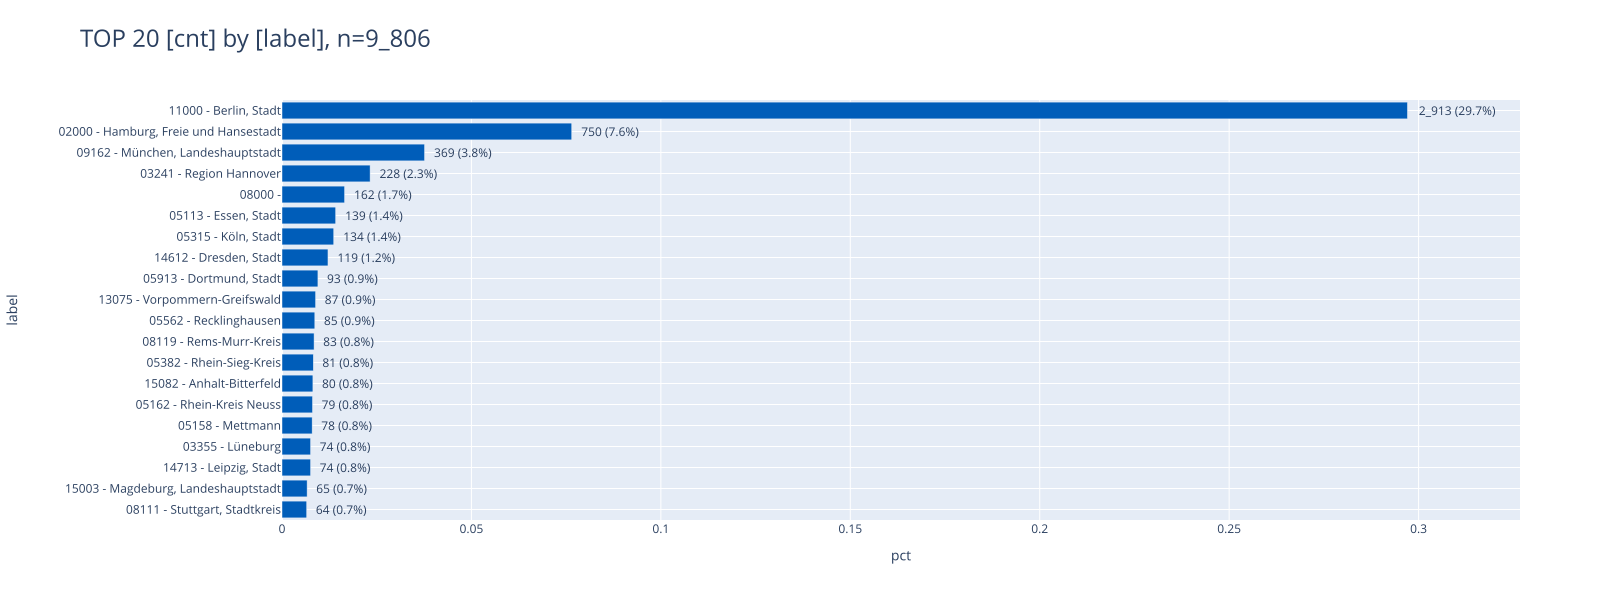

In [79]:
def show_duplikate_ort(db_duplicates, caption: str):
    _df = (db_duplicates
        .filter("not (Inzidenzort is null or Lieferregister is null)")
        .aggregate("Inzidenzort, count(*) as cnt")
        .join(dim_landkreis, "Inzidenzort::int = code", "left")
        .project("concat(Inzidenzort, ' - ', name) as label, cnt")
        .to_df()
    )#.set_index("Inzidenzort")
    # _df
    print(f"🟧 🗄️ {caption}")
    pls.plot_bars(_df, orientation="h",top_n_index=20, sort_values=True, height=600)

show_duplikate_ort(db_duplicates_clin,"klin")

🟧 🗄️ epi


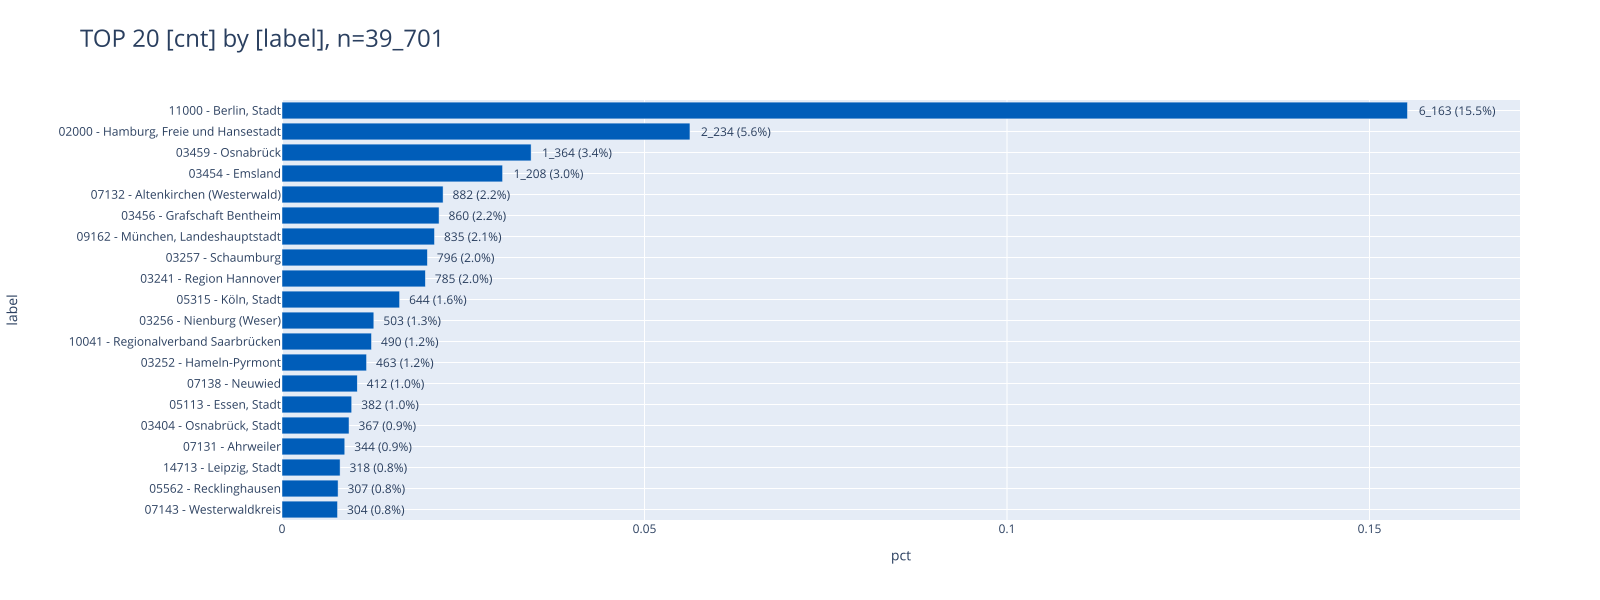

In [80]:
show_duplikate_ort(db_duplicates_epi,"epi")

<br>

#### <a id='toc1_5_2_2_'></a>[Verteilung nach Diagnosejahr](#toc0_)

🟧 🗄️ klin


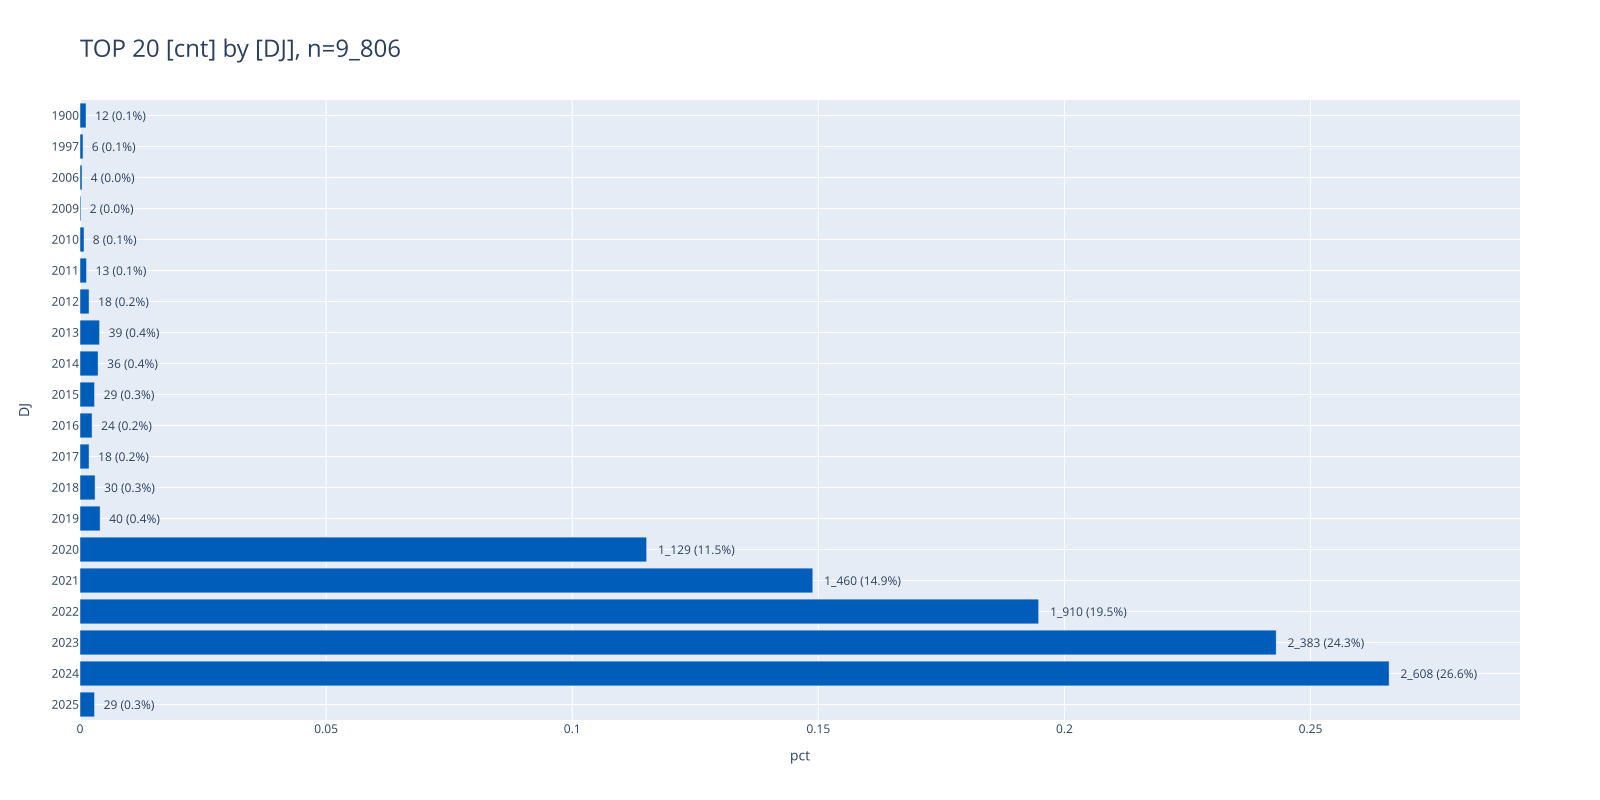

In [81]:
def show_duplikate_dj(db_duplicates, caption: str):
    _df = db_duplicates.aggregate("cast(Diagnosejahr as varchar) as DJ, count(*) as cnt").to_df()
    print(f"🟧 🗄️ {caption}")
    pls.plot_bars(_df, orientation="h",top_n_index=20, height=800, sort_values=False)

show_duplikate_dj(db_duplicates_clin, "klin")

🟧 🗄️ epi


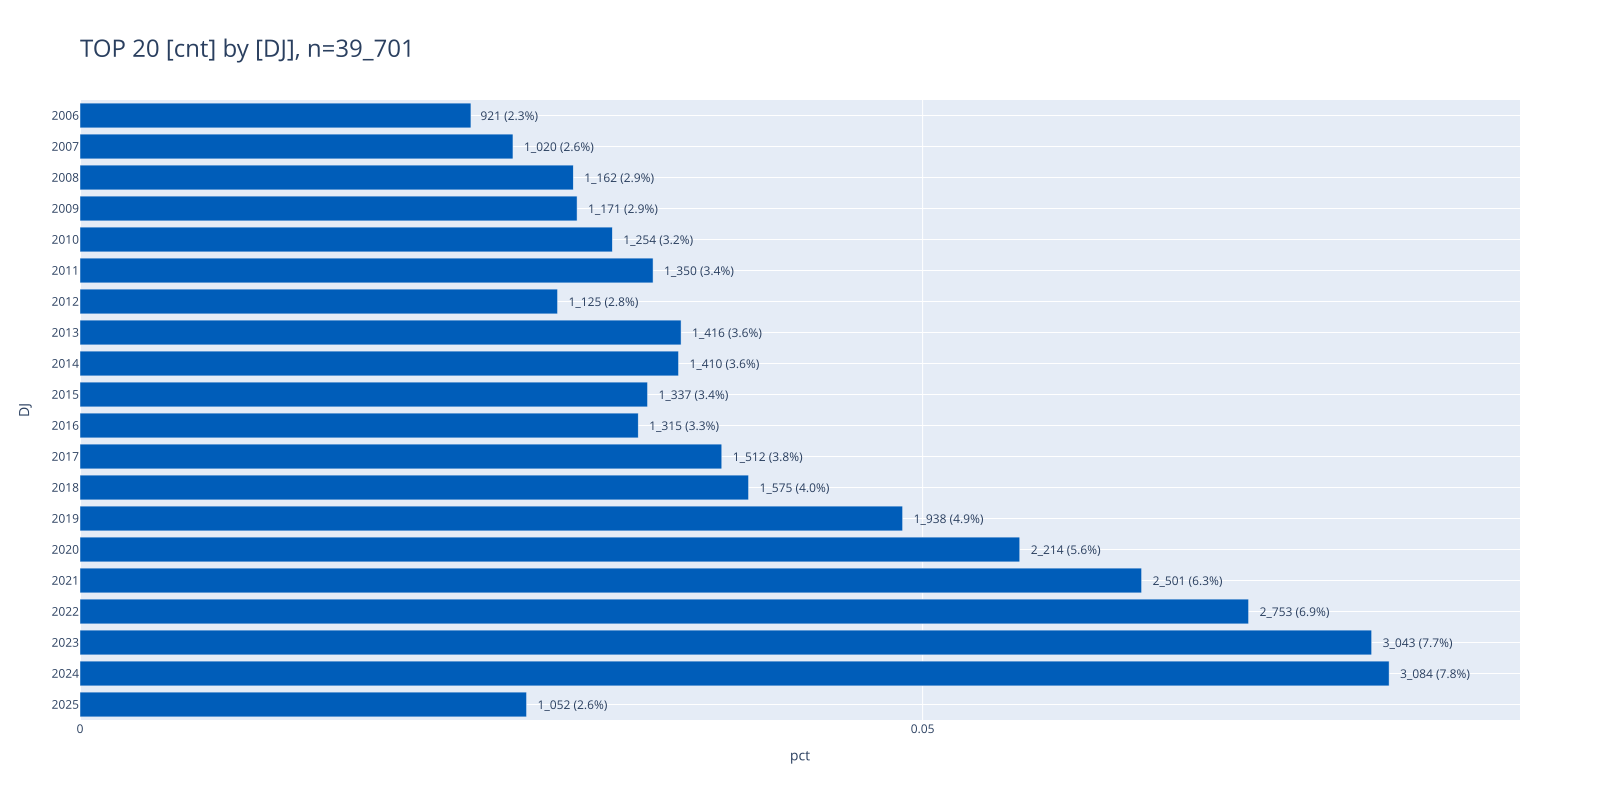

In [82]:
show_duplikate_dj(db_duplicates_epi, "epi")

<br>

#### <a id='toc1_5_2_3_'></a>[Verteilung nach ICD10](#toc0_)

🟧 🗄️ klin


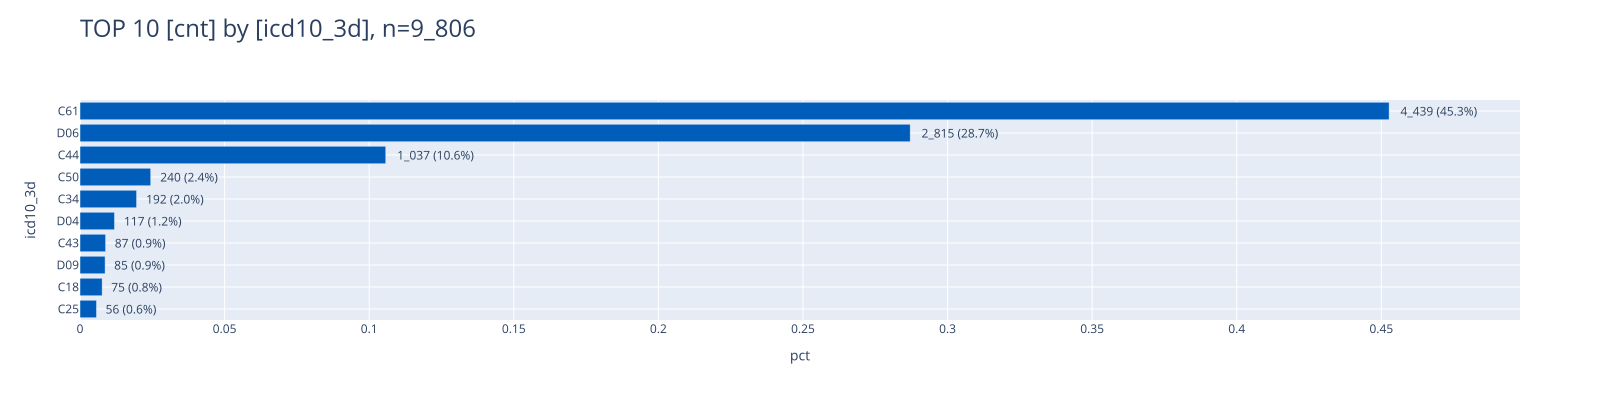

In [83]:
def show_duplikate_icd(db_duplicates, caption: str):
    _df = db_duplicates.aggregate("icd10_3d, count(*) as cnt").to_df()
    print(f"🟧 🗄️ {caption}")
    pls.plot_bars(_df, orientation="h",top_n_index=10, height=400, sort_values=True)

show_duplikate_icd(db_duplicates_clin, "klin")

🟧 🗄️ epi


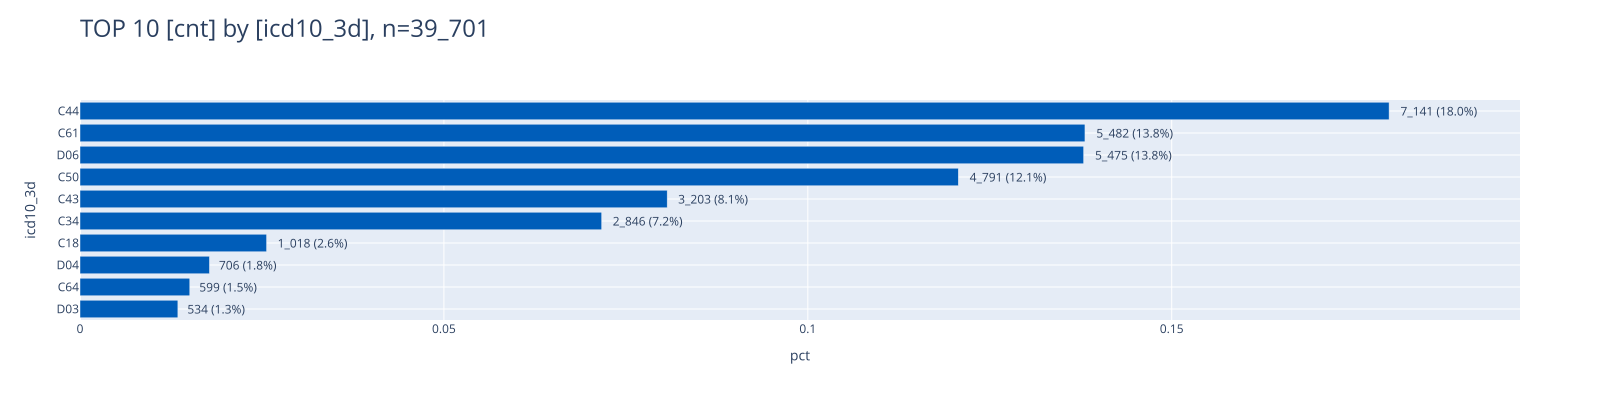

In [84]:
show_duplikate_icd(db_duplicates_epi, "epi")

<br>

#### <a id='toc1_5_2_4_'></a>[Verteilung der Gruppen mit gleichen Merkmalen](#toc0_)
- "_Gruppe_" = >1 Verdachtsfälle mit gleichen Merkmalen
- verwendete Metriken (jeweils aufgetragen: `is_equal` = "alle Fälle in der Gruppe haben den gleichen Wert")
> es gibt wenige Gruppen, in denen die Duplikate aus verschiedenen kkr stammen  
> in den meisten Gruppen stammen die Duplikate nicht von einem einzelnen Patienten  

In [85]:
def show_duplikate_grp(db_duplicates, caption: str):
    _df=(db_duplicates.aggregate("""--sql
        hash2, 
        min(Lieferregister) as kkr_min, max(Lieferregister) as kkr_max,
        min(oBDS_RKIPatientId) as pat_min, max(oBDS_RKIPatientId) as pat_max,
        count(*) as cnt
        """)
        .project("(kkr_max = kkr_min) as kkr_eq, (pat_max = pat_min) as pat_eq, cnt")
        .to_df()
    )

    print(f"🟧 🗄️ {caption}")
    print(f"{_df['cnt'].sum():_} Fälle verteilen sich auf {len(_df):_} Gruppen mit max {(_max:=_df['cnt'].max()):_} Fällen in einer Gruppe")
    print(f"Anzahl Gruppen, in denen alle Fälle das gleiche Merkmal aufweisen: REGISTER {_df['kkr_eq'].value_counts(normalize=False).to_dict()}")
    print(f"Anzahl Gruppen, in denen alle Fälle das gleiche Merkmal aufweisen: PATIENTID {_df['pat_eq'].value_counts(normalize=False).to_dict()}")

show_duplikate_grp(db_duplicates_clin,"klin")

🟧 🗄️ klin
9_806 Fälle verteilen sich auf 4_728 Gruppen mit max 14 Fällen in einer Gruppe
Anzahl Gruppen, in denen alle Fälle das gleiche Merkmal aufweisen: REGISTER {True: 4681, False: 47}
Anzahl Gruppen, in denen alle Fälle das gleiche Merkmal aufweisen: PATIENTID {False: 4277, True: 451}


In [86]:
show_duplikate_grp(db_duplicates_epi,"epi")

🟧 🗄️ epi
39_701 Fälle verteilen sich auf 19_470 Gruppen mit max 31 Fällen in einer Gruppe
Anzahl Gruppen, in denen alle Fälle das gleiche Merkmal aufweisen: REGISTER {True: 19470}
Anzahl Gruppen, in denen alle Fälle das gleiche Merkmal aufweisen: PATIENTID {False: 18095, True: 1375}


In [87]:
(db_duplicates_clin
    .order("oBDS_RKIPatientId")
    # .order("hash2")
    .project("""--sql
        hash2,
        --Tumor_ID,
        *
        exclude(oBDS_RKIPatientId, Tumor_ID)
    """)
    .filter("same_pat")
    .show(max_rows=50)
)

┌──────────────────────┬─────────────────────┬──────────────────┬──────────────────┬────────────────┬────────────────┬────────────────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬───────────────────┬────────────────┬──────────┬──────────────┬─────────────┬─────────────┬────────────┬────────────┬──────────────┬──────────────────────────┬───────────────┬───────────────────────────┬───────────────────┬───────────────────────────────┬──────────────────────┬──────────────────────┬───────┬──────────┬──────────┐
│        hash2         │ Diagnose_ICD10_Code │ Morphologie_Code │ Topographie_Code │ UICC_Stadium_c │ UICC_Stadium_p │ Seitenlokalisation │   T_c   │   T_p   │ Grading │   N_p   │   N_c   │   M_c   │   M_p   │ Diagnosesicherung │ Lieferregister │ icd10_3d │ Diagnosejahr │ Inzidenzort │ Geburtsjahr │ Geschlecht │ Verstorben │ Geburtsdatum │ Geburtsdatum_Genauigkeit │ Diagnosedatum │ Diagnosedatum_Genauigkeit │ Datum_Vitalstatus │ Datum_Vitalstatus_Genauigk

In [ ]:
if False:
    df_pivot = (db_epi
        .filter("GKZbl::int <= 16")
        # .project("")
        .project("""
                GKZbl, DJ::text as DJ, is_deleted::bool as is_deleted, IARC, DCO
                ,case when IARC like '%A_Mehr%' then true else false end as is_multiple
                ,case when IARC like '%A_ICD10_keineAuswertung%' then true else false end as has_wrong_icd10
            """)
        .aggregate("GKZbl, DJ, is_deleted, IARC, DCO, count(*) as cnt, is_multiple, has_wrong_icd10")
        .to_df()
    )
    spec = "config/epi_pygwalker_spec.json"
    hlp.add_measures_to_pyg_config(spec, nodes=[("cnt_tum","sum(cnt)")])

    import pygwalker as pyg

    pyg.walk(df_pivot, appearance=os.getenv("THEME"), kernel_computation=True, spec=spec)

## <a id='toc1_6_'></a>[Datensatz](#toc0_)

🔵 *** df: Tumor (id excluded) ***  
🟣 shape: (4_015_983, 101)
🟣 duplicates: 868 (0%)  
🟠 column stats all (dtype | uniques | missings) [values]  
- index [0, 1, 2, 3, 4,]  
- Diagnosedatum (datetime64[us] | 722 | 0 (0%)) [1900-04-01 00:00:00, 1937-07-15 00:00:00, 1941-01-15 00:00:00, 1945-07-01 00:00:00,  
1948-03-15 00:00:00,]  
- Diagnosedatum_Genauigkeit (object | 3 | 0 (0%)) ['M', 'T', 'V',]  
- Inzidenzort (object | 494 | 1_000 (0%)) ['01001', '01002', '01003', '01004', '01051',]  
- Diagnose_ICD10_Code (object | 884 | 393 (0%)) ['<NA>', 'C00', 'C00.0', 'C00.1', 'C00.2',]  
- Diagnose_ICD10_Version (object | 38 | 114_018 (3%)) ['10 2004 GM', '10 2005 GM', '10 2006 GM', '10 2008 GM', '10 2009 GM',]  
- Topographie_Code (object | 709 | 28_994 (1%)) ['<NA>', 'C00.0', 'C00.1', 'C00.2', 'C00.3',]  
- Topographie_Version (object | 4 | 128_889 (3%)) ['31', '32', '33', '<NA>',]  
- Diagnosesicherung (object | 12 | 0 (0%)) ['0', '1', '2', '4', '5',]  
- TNM_Auflage_c (object | 5 | 1_829_49

<!-- START_TOKEN -->

<!-- END_TOKEN -->

┌─────────────────────┬──────────────────────┬─────────────┬───┬─────────┬──────────────────────┬──────────────────────┐
│    Diagnosedatum    │ Diagnosedatum_Genau… │ Inzidenzort │ … │  z_sex  │ z_period_diag_death… │ z_period_diag_psa_d… │
│      timestamp      │       varchar        │   varchar   │ … │ varchar │        int32         │        int32         │
├─────────────────────┼──────────────────────┼─────────────┼───┼─────────┼──────────────────────┼──────────────────────┤
│ 2023-01-15 00:00:00 │ T                    │ 03256       │ … │ M       │                 NULL │                 NULL │
│ 2022-10-15 00:00:00 │ T                    │ 01001       │ … │ W       │                 NULL │                 NULL │
│ 2022-09-15 00:00:00 │ T                    │ 08116       │ … │ M       │                 NULL │                 NULL │
└─────────────────────┴──────────────────────┴─────────────┴───┴─────────┴──────────────────────┴──────────────────────┘
  3 rows                        

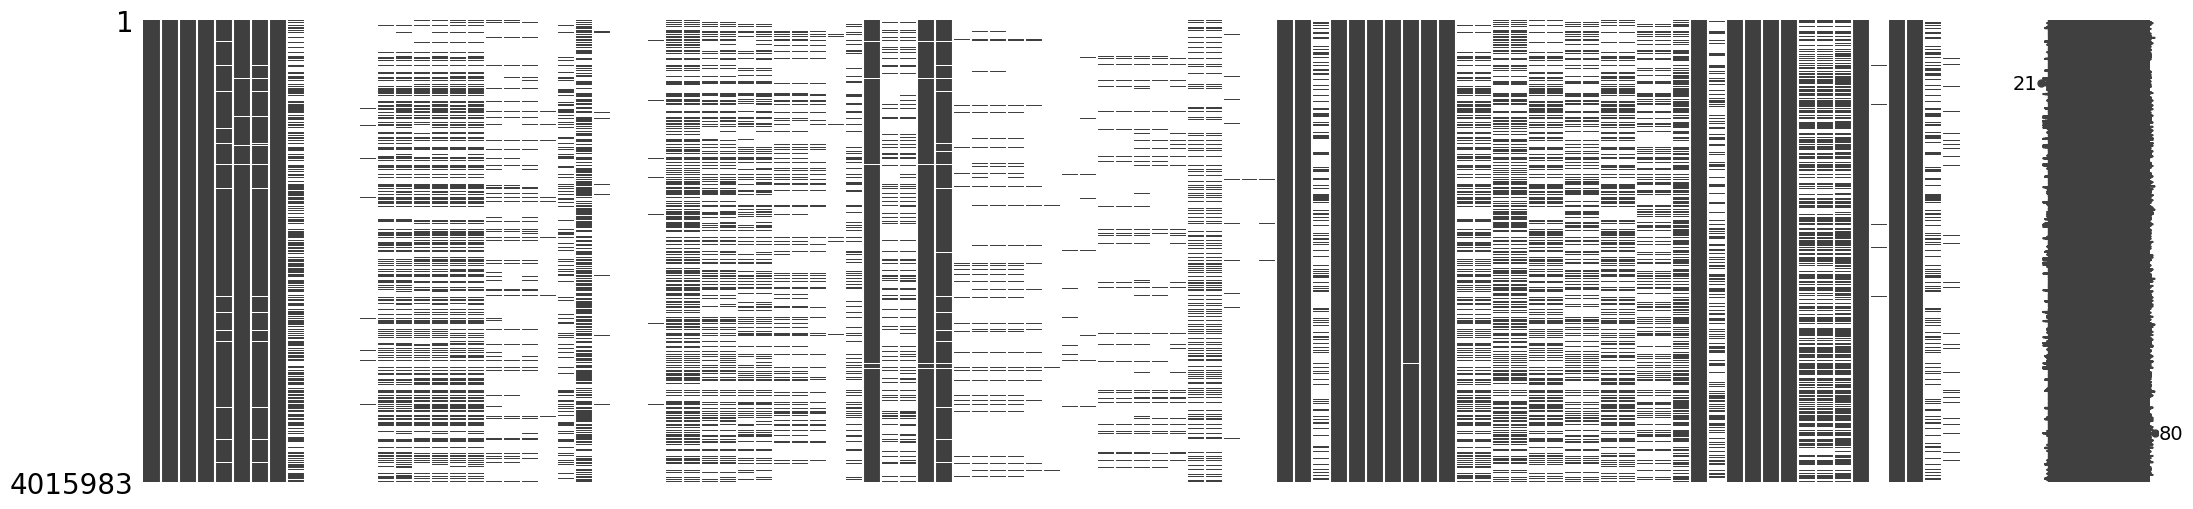

In [88]:
tbl.describe_df(
    Tumor.project("* exclude(z_tum_id, z_pat_id, oBDS_RKIPatientTumorId, oBDS_RKIPatientId)").to_df(),
    "Tumor (id excluded)",
    fig_cols=4,
    top_n_chars_in_columns=20,
    top_n_chars_in_index=10,
    use_missing=True,
)